In [160]:
import pandas as pd
import numpy as np
import fuzzywuzzy
import seaborn as sns
import matplotlib.pyplot as plt
from fuzzywuzzy import process, fuzz

In [161]:
# Load the dataset
banks_df = pd.read_csv("messy_south_african_bank_dataset.csv")
banks_df.head()

,Customer_ID,Age,Gender,Province,Employment_Status,Monthly_Income_ZAR,Account_Type,Account_Balance_ZAR,Monthly_Transactions,Avg_Transaction_Value_ZAR,Loan_Status,Loan_Amount_ZAR,Credit_Score,Missed_Payments_Last_6M,Digital_Banking_Usage,Customer_Tenure_Years
0,1001,34,Male,Western Cape,Employed,25000.0,Cheque,12000.0,45,320,Active Loan,80000,680.0,1,High,5
1,1002,29,Female,Gauteng,Employed,NaN,Savings,8000.0,30,250,No Loan,0,720.0,0,High,3
2,1003,45,Male,KZN,Self-Employed,22000.0,Cheque,5000.0,25,400,Active Loan,120000,640.0,2,Medium,7
3,1004,52,Female,Eastern Cape,Unemployed,5000.0,Savings,1500.0,10,150,Defaulted,30000,520.0,4,Low,10
4,1005,39,Male,Gauteng,Employed,30000.0,Credit,20000.0,60,500,Active Loan,150000,700.0,0,High,6


In [162]:
# Check the structure of the dataset
banks_df.info()
banks_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer_ID                31 non-null     int64  
 1   Age                        31 non-null     int64  
 2   Gender                     31 non-null     object 
 3   Province                   31 non-null     object 
 4   Employment_Status          31 non-null     object 
 5   Monthly_Income_ZAR         30 non-null     float64
 6   Account_Type               31 non-null     object 
 7   Account_Balance_ZAR        30 non-null     float64
 8   Monthly_Transactions       31 non-null     int64  
 9   Avg_Transaction_Value_ZAR  31 non-null     int64  
 10  Loan_Status                31 non-null     object 
 11  Loan_Amount_ZAR            31 non-null     int64  
 12  Credit_Score               30 non-null     float64
 13  Missed_Payments_Last_6M    31 non-null     int64  
 

Customer_ID                  0
Age                          0
Gender                       0
Province                     0
Employment_Status            0
Monthly_Income_ZAR           1
Account_Type                 0
Account_Balance_ZAR          1
Monthly_Transactions         0
Avg_Transaction_Value_ZAR    0
Loan_Status                  0
Loan_Amount_ZAR              0
Credit_Score                 1
Missed_Payments_Last_6M      0
Digital_Banking_Usage        0
Customer_Tenure_Years        0
dtype: int64

In [163]:
# Drop the columns that are not needed for analysis
banks_df.drop(columns=['Customer_ID', 'Gender','Customer_Tenure_Years' ], inplace=True)

In [164]:
# Drop columns with blank cells
banks_df = banks_df.dropna()
banks_df.head()

,Age,Province,Employment_Status,Monthly_Income_ZAR,Account_Type,Account_Balance_ZAR,Monthly_Transactions,Avg_Transaction_Value_ZAR,Loan_Status,Loan_Amount_ZAR,Credit_Score,Missed_Payments_Last_6M,Digital_Banking_Usage
0,34,Western Cape,Employed,25000.0,Cheque,12000.0,45,320,Active Loan,80000,680.0,1,High
2,45,KZN,Self-Employed,22000.0,Cheque,5000.0,25,400,Active Loan,120000,640.0,2,Medium
3,52,Eastern Cape,Unemployed,5000.0,Savings,1500.0,10,150,Defaulted,30000,520.0,4,Low
4,39,Gauteng,Employed,30000.0,Credit,20000.0,60,500,Active Loan,150000,700.0,0,High
5,39,Gauteng,Employed,30000.0,Credit,20000.0,60,500,Active Loan,150000,700.0,0,High


In [165]:
# Original unique provinces
provinces = banks_df['Province'].unique()
print(f"There are {len(provinces)} unique provinces")
provinces

There are 9 unique provinces


array(['Western Cape', 'KZN', 'Eastern Cape', 'Gauteng', 'Limpopo',
       'Free State', 'Northern Cape', 'GP', 'Kwazulu-Natal'], dtype=object)

In [166]:
# Remove leading white spaces
banks_df['Province'] = banks_df['Province'].str.lstrip()

In [ ]:
# Encode Digital_Banking_Usage to numerical values
banks_df['Digital_Banking_Usage_Encoded'] = banks_df['Digital_Banking_Usage'].map(usage_mapping)

In [173]:
# Encode Digital_Banking_Usage to numerical values
banks_df['Digital_Banking_Usage_Encoded'] = banks_df['Digital_Banking_Usage'].map(usage_mapping)

In [174]:
# Correlation between Digital Banking Usage and Defaulted
digital_usage_default_correlation = banks_df['Digital_Banking_Usage_Encoded'
].corr(banks_df['Defaulted'])

print(f"Correlation between Digital Banking Usage and Defaulted Loans: {digital_usage_default_correlation:.4f}")

Correlation between Digital Banking Usage and Defaulted Loans: -0.8581


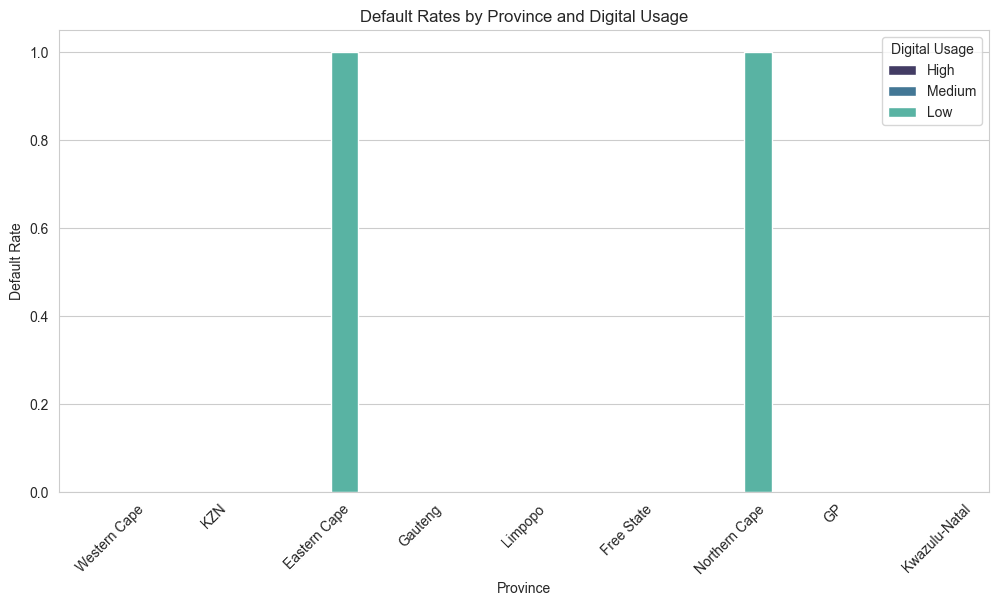

In [175]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate mean default rate by Province and Digital Usage
plt.figure(figsize=(12,6))

sns.barplot(
    data=banks_df,
    x='Province',
    y='Defaulted',
    hue='Digital_Banking_Usage',
    estimator='mean',
    palette='mako'
)

plt.title('Default Rates by Province and Digital Usage')
plt.xlabel('Province')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)

plt.legend(title='Digital Usage')
plt.show()

In [88]:
# Montly income vs credit score
Monthly_Income_Credit_Score_Correlation = banks_df['Monthly_Income_ZAR'].corr(banks_df['Credit_Score'])
print(f"Correlation between Monthly Income and Credit Score: {Monthly_Income_Credit_Score_Correlation:.3f}")

Correlation between Monthly Income and Credit Score: 0.835


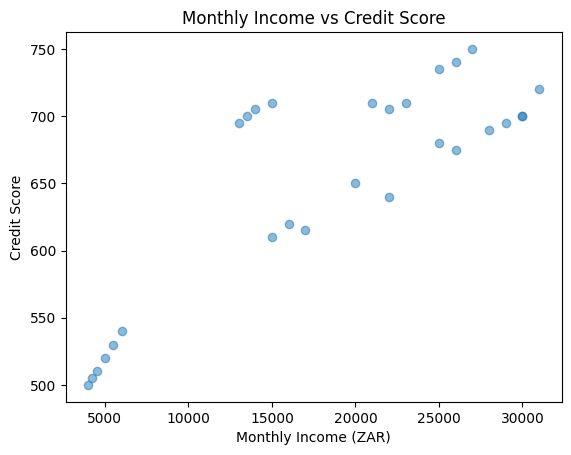

In [ ]:
# Data story 2

# Plotting the relationship between Monthly Income and Credit Score
plt.scatter(banks_df['Monthly_Income_ZAR'], banks_df['Credit_Score'], alpha=0.5)
plt.title('Monthly Income vs Credit Score')
plt.xlabel('Monthly Income (ZAR)')
plt.ylabel('Credit Score')
plt.show()

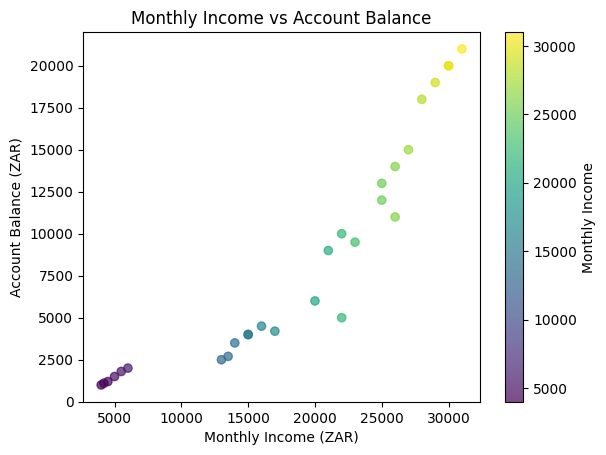

In [ ]:
#Data story 3

# Buying behaviours: Monthly Income vs Account_Balance_ZAR
plt.scatter(banks_df['Monthly_Income_ZAR'],banks_df['Account_Balance_ZAR'],
    c=banks_df['Monthly_Income_ZAR'],
    cmap='viridis',
    alpha=0.7
)
plt.colorbar(label='Monthly Income')
plt.title('Monthly Income vs Account Balance')
plt.xlabel('Monthly Income (ZAR)')
plt.ylabel('Account Balance (ZAR)')
plt.show()
